# Solving the Max-Cut Problem: From Brute Force to Quantum Abstraction

## Overview
The **Max-Cut problem** is a classic combinatorial optimization challenge. Given a graph, the goal is to partition the vertices into two sets such that the number of edges (or total weight of edges) between the sets is maximized.

## Practical Applications
Real-world problems naturally map to Max-Cut instances. Consider a social network where:
- **Vertices** represent individuals
- **Edges** represent interactions/influence between people
- **Weights** quantify the strength of influence

A common application is **targeted marketing**: if offering free products to certain individuals influences others to buy, Max-Cut helps identify the optimal subset of recipients to maximize total revenue by maximizing the "cut" between those who receive free products and those influenced to purchase.

This problem is **NP-hard**, making it a primary candidate for benchmarking quantum algorithms like the **Quantum Approximate Optimization Algorithm (QAOA)** and **Variational Quantum Eigensolver (VQE)**.

## The Abstraction Ladder
This notebook is designed to show the evolution of solving techniques:
1. **Brute Force:** Testing every possible combination (only viable for very small graphs).
2. **Manual Quantum Mapping:** Manually deriving the Ising Hamiltonian from the graph's topology.
3. **Qiskit Optimization (Intermediate):** Using application modules to automate the Hamiltonian (Qubit Operator) generation.
4. **Qiskit Optimization (High-Level):** Using the `MinimumEigenOptimizer` to solve the problem as a "Quadratic Program," completely abstracting away the underlying quantum circuits.

## Technical Stack
* **Graph Engine:** `rustworkx` (High-performance graph library).
* **Quantum Backend:** Qiskit Primitives (Sampler).
* **Optimization:** `qiskit-optimization` and `qiskit-algorithms`.

### Setup and Imports

In [19]:
# Standard libraries for math and plotting
import numpy as np
import matplotlib.pyplot as plt
import rustworkx as rx
from rustworkx.visualization import mpl_draw

# Qiskit Algorithms & Primitives
from qiskit.primitives import StatevectorSampler as Sampler
from qiskit.circuit.library import n_local
from qiskit_algorithms.optimizers import SPSA

# Qiskit Optimization (Abstract Modules)
from qiskit_optimization.applications import Maxcut
from qiskit_optimization.algorithms import MinimumEigenOptimizer
from qiskit_optimization.minimum_eigensolvers import NumPyMinimumEigensolver, SamplingVQE
from qiskit_optimization.utils import algorithm_globals

# Set seed for reproducibility
algorithm_globals.random_seed = 123

print("✓ Libraries imported. High-performance rustworkx ready.")

✓ Libraries imported. High-performance rustworkx ready.


### Graph and Plot

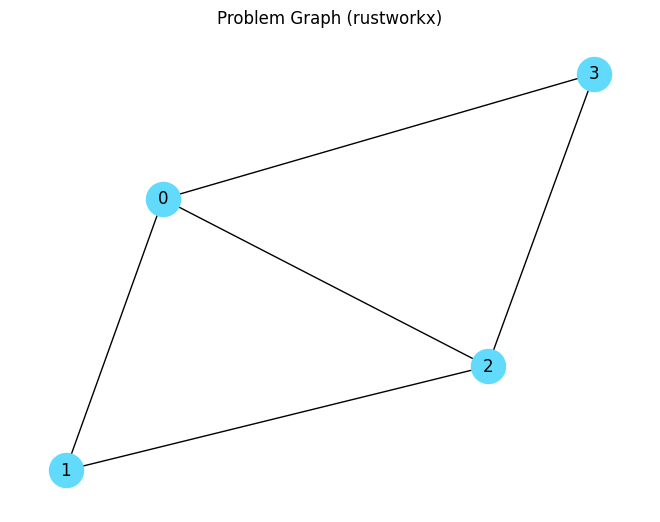

In [35]:
# Create a 4-node graph with 5 edges using rustworkx
n = 4
graph = rx.PyGraph()
graph.add_nodes_from(range(n))
edges = [(0, 1, 1.0), (0, 2, 1.0), (0, 3, 1.0), (1, 2, 1.0), (2, 3, 1.0)]
graph.add_edges_from(edges)

# Using a seed makes the layout consistent across notebook restarts.
pos = rx.spring_layout(graph, seed=123)

# Visualization
mpl_draw(graph, pos=pos, with_labels=True, node_color='#61dafb', node_size=600)
plt.title("Problem Graph (rustworkx)")
plt.show()

In [8]:
# Generate adjacency matrix for later use
adj_matrix = rx.adjacency_matrix(graph)
adj_matrix

array([[0., 1., 1., 1.],
       [1., 0., 1., 0.],
       [1., 1., 0., 1.],
       [1., 0., 1., 0.]])

### Brute Force Classical

In [ ]:
best_cost = 0
best_partition = None

# Iterate through all 2^n possible bitstrings
for i in range(2**n):
    # Convert integer to bitstring (e.g., [0, 1, 0, 1])
    x = [int(bit) for bit in bin(i)[2:].zfill(n)]
    
    # Calculate cut: weight of edges where nodes are in different sets
    current_cost = 0
    for u, v, w in edges:
        if x[u] != x[v]:
            current_cost += w
            
    if current_cost > best_cost:
        best_cost = current_cost
        best_partition = x

print(f"Brute Force Best Partition: {best_partition}")
print(f"Brute Force Max Cut Value: {best_cost}")

Brute Force Best Partition: [0, 1, 0, 1]
Brute Force Max Cut Value: 4.0


### CLASSICAL ABSTRACTION (NumPyMinimumEigensolver)

In [12]:
# Use the Maxcut application class to bridge the graph and optimization
maxcut_app = Maxcut(adj_matrix)
qp = maxcut_app.to_quadratic_program()

print(f"Quadratic Problem: \n{qp}\n")

# Solve exactly using a classical eigensolver wrapped in Qiskit Opt
exact_solver = MinimumEigenOptimizer(NumPyMinimumEigensolver())
exact_result = exact_solver.solve(qp)

print(f"Classical Opt Result: {exact_result.x}")
print(f"Classical Opt Value: {exact_result.fval}")

Quadratic Problem: 
maximize -2*x_0*x_1 - 2*x_0*x_2 - 2*x_0*x_3 - 2*x_1*x_2 - 2*x_2*x_3 + 3*x_0 + 2*x_1 + 3*x_2 + 2*x_3 (4 variables, 0 constraints, 'Max-cut')

Classical Opt Result: [1. 0. 1. 0.]
Classical Opt Value: 4.0


### HAMILTONIAN (Manual Vs Auto)

In [17]:
from qiskit.quantum_info import SparsePauliOp

# Manual Ising mapping: Edge (i, j) -> 0.5 * (I - ZiZj)
pauli_list = []
for i, j, w in edges:
    z_string = ["I"] * n
    z_string[i] = "Z"
    z_string[j] = "Z"
    pauli_list.append(("".join(z_string), 0.5 * w))

# The cost Hamiltonian is the sum of these terms
qubitOp = SparsePauliOp.from_list(pauli_list)
print("Manual Ising Hamiltonian:")
print(qubitOp)
offset = -sum(edge[2] for edge in edges) / 2
print(f"Offset: {offset}")

# Convert the Quadratic Program to an Ising Hamiltonian using QuadraticProgram
# This is the 'Qubit Operator' bridge
# Use the Maxcut application class to bridge the graph and optimization
maxcut_app = Maxcut(adj_matrix)
qp = maxcut_app.to_quadratic_program()
qubitOp, offset = qp.to_ising()

print("\nAuto Ising Hamiltonian:")
print(str(qubitOp))
print(f"Offset: {offset}")

Manual Ising Hamiltonian:
SparsePauliOp(['ZZII', 'ZIZI', 'ZIIZ', 'IZZI', 'IIZZ'],
              coeffs=[0.5+0.j, 0.5+0.j, 0.5+0.j, 0.5+0.j, 0.5+0.j])
Offset: -2.5

Auto Ising Hamiltonian:
SparsePauliOp(['IIZZ', 'IZIZ', 'ZIIZ', 'IZZI', 'ZZII'],
              coeffs=[0.5+0.j, 0.5+0.j, 0.5+0.j, 0.5+0.j, 0.5+0.j])
Offset: -2.5


### QUANTUM CIRCUIT

In [ ]:
# Using n_local with RY gates and CZ entanglement as requested
ansatz = n_local(qubitOp.num_qubits, "ry", "cz", reps=5, entanglement="linear")

# Setup the Optimizer and VQE
optimizer = SPSA(maxiter=300)

sampler = Sampler()

vqe = SamplingVQE(sampler=sampler, ansatz=ansatz, optimizer=optimizer)

### Qiskit Optimization (Intermediate Abstraction)

energy: -1.4990234375
time: 6.1942298412323
max-cut objective: -3.9990234375
solution: [0 1 0 1]
solution objective: 4.0


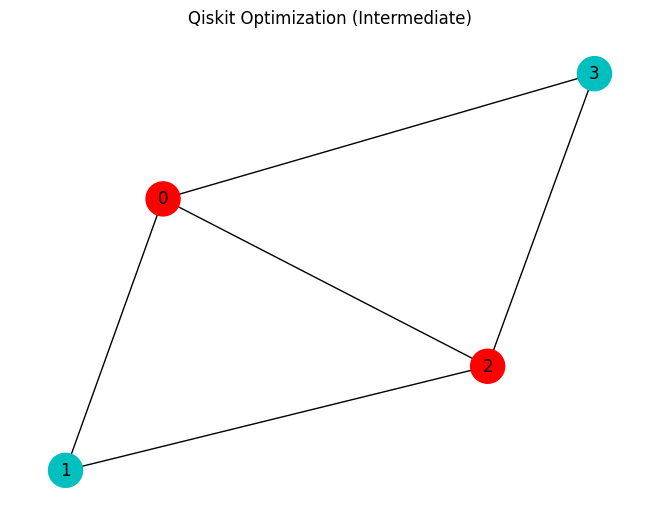

In [36]:
# simple abstraction
vqe_result = vqe.compute_minimum_eigenvalue(qubitOp)

# 5. Interpret the result back to the original problem domain
# This maps the quantum result back to the Max-Cut partition
actual_cut = maxcut_app.sample_most_likely(vqe_result.eigenstate)
print("energy:", vqe_result.eigenvalue.real)
print("time:", vqe_result.optimizer_time)
print("max-cut objective:", vqe_result.eigenvalue.real + offset)
print("solution:", actual_cut)
print("solution objective:", qp.objective.evaluate(actual_cut))

# Visualize the resulting cut
colors = ["r" if actual_cut[i] == 0 else "c" for i in range(n)]
pos = rx.spring_layout(graph, seed=123)
mpl_draw(graph, pos=pos, with_labels=True, node_color=colors, node_size=600)
plt.title("Qiskit Optimization (Intermediate)")
plt.show()

### Qiskit Optimization (High-level Abstraction)

High-Level Abstract Result: [0. 1. 0. 1.]
High-Level Abstract Value: 4.0


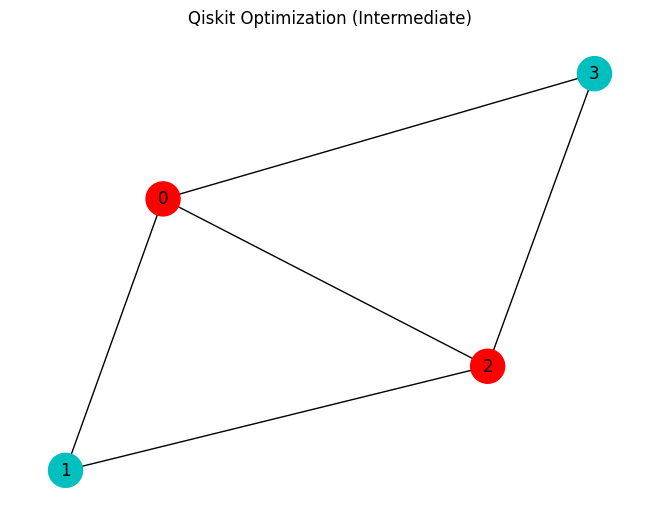

In [37]:
# In this approach, we use the MinimumEigenOptimizer as a high-level bridge.
# It automatically handles the 'to_ising' conversion and result interpretation.

vqe_optimizer = MinimumEigenOptimizer(vqe)
final_result = vqe_optimizer.solve(qp)

# ============================================================================
# FINAL RESULTS AND VISUALIZATION
# ============================================================================
print(f"High-Level Abstract Result: {final_result.x}")
print(f"High-Level Abstract Value: {final_result.fval}")

# Visualize the resulting cut
colors = ["r" if final_result.x[i] == 0 else "c" for i in range(n)]
pos = rx.spring_layout(graph, seed=123)
mpl_draw(graph, pos=pos, with_labels=True, node_color=colors, node_size=600)
plt.title("Qiskit Optimization (Intermediate)")
plt.show()

# Conclusions and Key Takeaways

## The Value of Abstraction
By progressing through this notebook, we have moved from manual bit-flipping (Brute Force) to a fully automated quantum pipeline:

1.  **Physics vs. Logic:** We interacted with the **Ising Hamiltonian** (`qubitOp`). This is useful for researchers who need to inspect the energy landscape.
2.  **The "Application" Layer:** In the high-level abstration section, the `MinimumEigenOptimizer` allowed us to ignore the quantum mechanics entirely. We provided a `QuadraticProgram` and received a solution in the problem domain (bitstrings).
3.  **Ansatz Customization:** By using `n_local` with `RY` gates and `linear` entanglement, we tailored the quantum circuit to be more expressive than a standard hardware-efficient ansatz.
4. **SPSA (Stochastic Perturbation Simultaneous Approximation) optimizer** Unlike COBYLA, which is a derivative-free direct search, SPSA approximates the gradient. It is specifically designed for high-dimensional optimization where the function evaluation is noisy or expensive, which is typical for VQE implementations on real hardware.